# Single-cell Quality Control & Immune Repertoire Analysis (Figure S1)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure S1a–e** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to perform rigorous quality control (QC) and characterize the immune repertoire landscape of ENKTCL patients. Specifically, we:
1.  Evaluate the distribution of Unique Molecular Identifiers (UMIs) and detected genes across different cell types and patient samples to ensure data robustness.
2.  Inspect the raw data structure via UMAP to observe batch clustering and treatment status distribution prior to correction.
3.  Analyze the diversity of immune receptors, specifically focusing on receptor types and chain pairing status within the immune microenvironment.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import scirpy as ir
import numpy as np
import os
import seaborn as sns
from scipy.sparse import csc_matrix, csr_matrix
import sys
print(sys.version)

In [710]:
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, PercentFormatter
figPath = "./figures/figS1"
datPath = "./data/NKTCL_concat.h5ad"
irPath = "./data/NKTCL-ir.h5ad"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14

In [ ]:
adata_concat = sc.read_h5ad(datPath)
adata_concat.var_names = list(adata_concat.var_names)
adata_concat.var_names_make_unique()
nktcl_ir = sc.read_h5ad(irPath)
nktcl_ir

AnnData object with n_obs × n_vars = 60443 × 0
    obs: 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'cc_aa_alignment', 'cc_aa_alignment_size', 'clonotype_modularity', 'clonotype_modularity_fdr'
    uns: 'chain_indices', 'scirpy_version', 'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_alignment', 'cc_aa_alignment', 'clonotype_network'
    obsm: 'airr', 'chain_indices', 'X_clonotype_network'

#### **Fig. S1a** Counts of unique molecular identifiers (UMIs) and genes for each major cell type in this study.

/tmp/ipykernel_3335451/4094394553.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(adata_concat.obs['anno-pca'].cat.categories, rotation=45)


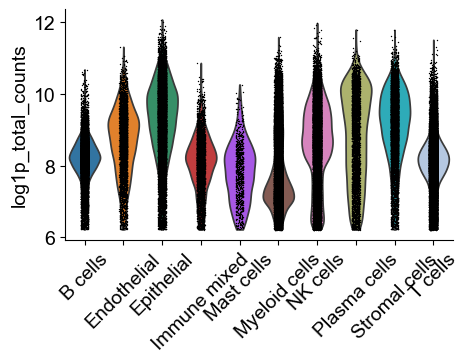

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sc.pl.violin(adata_concat, keys=['log1p_total_counts'], groupby='anno-pca', ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_concat.obs['anno-pca'].cat.categories, rotation=45)
fig.savefig(f"{figPath}/FigS1a-total.pdf", bbox_inches='tight')

/tmp/ipykernel_3335451/3449215429.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(adata_concat.obs['anno-pca'].cat.categories, rotation=45)


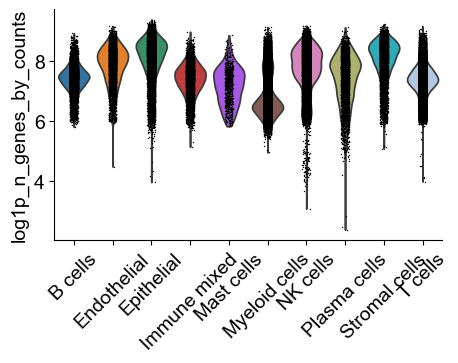

In [712]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sc.pl.violin(adata_concat, keys=['log1p_n_genes_by_counts'], groupby='anno-pca', ax=ax,show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_concat.obs['anno-pca'].cat.categories, rotation=45)
fig.savefig(f"{figPath}/FigS1a-genes.pdf", dpi=400, bbox_inches='tight')

#### **Fig. S1b** Counts of UMIs and genes per sample in this study.

/tmp/ipykernel_3335451/3082093409.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(adata_concat.obs['batch'].cat.categories, rotation=90)


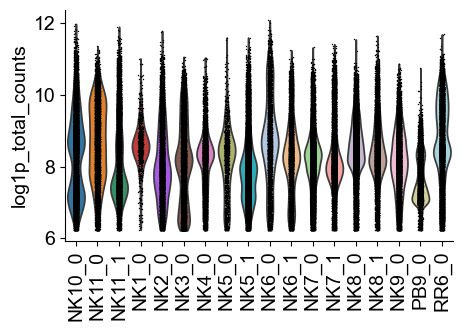

In [714]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sc.pl.violin(adata_concat, keys=['log1p_total_counts'], groupby='batch', ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_concat.obs['batch'].cat.categories, rotation=90)
fig.savefig(f"{figPath}/FigS1b-total.pdf", bbox_inches='tight')

/tmp/ipykernel_3335451/1643682144.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(adata_concat.obs['batch'].cat.categories, rotation=90)


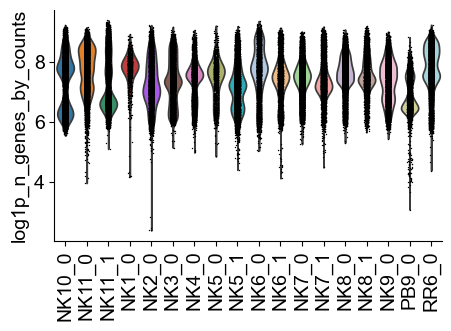

In [716]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sc.pl.violin(adata_concat, keys=['log1p_n_genes_by_counts'], groupby='batch', ax=ax,show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_concat.obs['batch'].cat.categories, rotation=90)
fig.savefig(f"{figPath}/FigS1b-genes.pdf", dpi=400, bbox_inches='tight')

#### **Fig. S1c** UMAP visualization of all cells without batch correction, colored by batch names.

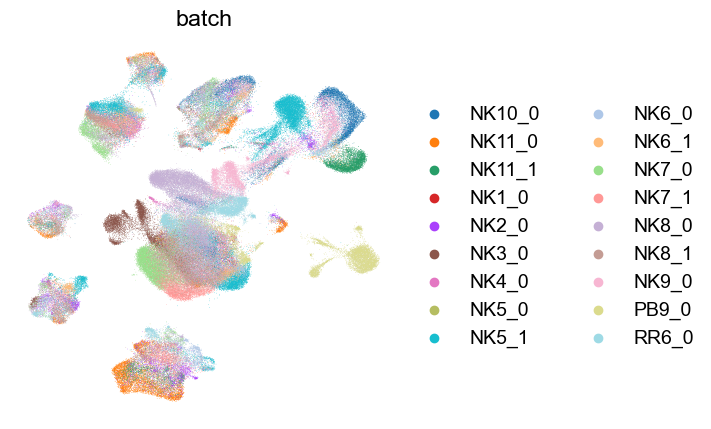

In [717]:
fig, ax = plt.subplots(figsize=(5,5))
sc.pl.umap(adata_concat, color=['batch'], ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/FigS1c.png', dpi=400, bbox_inches='tight')

#### **Fig. S1d** UMAP visualization of all cells without batch correction, colored by treatment status.

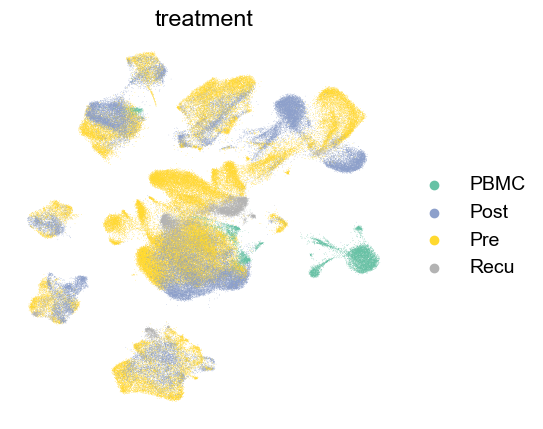

In [718]:
fig, ax = plt.subplots(figsize=(5,5))
sc.pl.umap(adata_concat, color=['treatment'], ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/FigS1d.png', dpi=400, bbox_inches='tight')

#### **Fig. S1e** UMAP visualization of immune repertoire, colored by receptor types and chain pairing status.

In [719]:
mdata = mu.MuData({'gex': adata_concat, "airr":nktcl_ir})
mdata

/home/rzh/miniconda3/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rzh/miniconda3/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 170505 × 33727
  2 modalities
    gex:	170213 x 33727
      obs:	'batch', 'mt_frac', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'leiden-1', 'leiden-pca', 'anno-pca', 'treatment', 'cnv_status', 'cnv_score', 'cellTypeLabels', 'CellStateLabels'
      var:	'ID', 'name', 'type', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'CellStateLabels_colors', 'anno-pca_colors', 'batch_colors', 'cnv_status_colors', 'dendrogram_anno-pca', 'hvg', 'leiden', 'leiden-1_colors', 'leiden-pca_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'treatment_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap'
      varm:	'PCs'
      layers:	'Raw'
      obsp:	'connectivities', 'distances'
    airr:	60443 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'cc_aa_alignment', 'cc_aa_alignment_size', 'clonotype_modularity', 'clonotype_modularity_fdr'
      uns:	'chain_indices', 'scirpy_version', 'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_identity', 'ir_dist_aa_alignment', 'cc_aa_alignment', 'clonotype_network'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

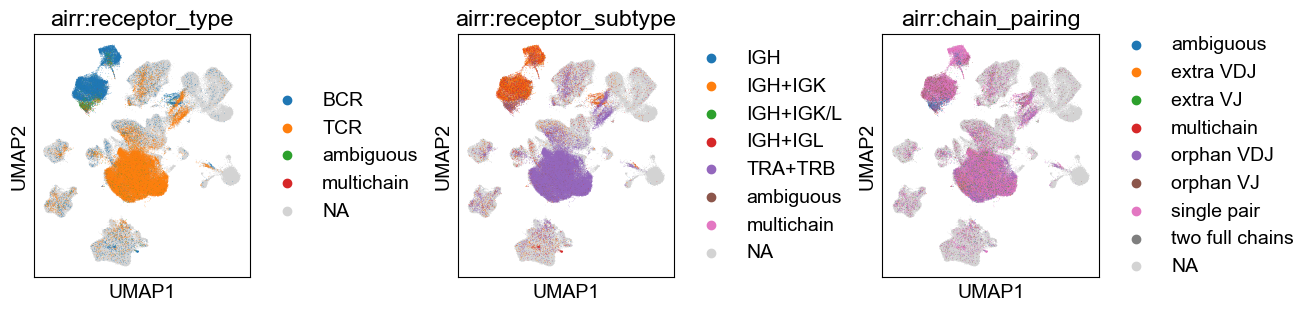

In [720]:
# umap of TCR,BCR 
fig, ax = plt.subplots(1, 3,figsize=(13,3), constrained_layout=True)
for i,g in enumerate(["airr:receptor_type", "airr:receptor_subtype", 'airr:chain_pairing']):
  mu.pl.embedding(mdata, basis="gex:umap", color=g, ax=ax[i], show=False)
  ax[i].set_xlabel("UMAP1")
  ax[i].set_ylabel("UMAP2")
fig.savefig(f"{figPath}/Fig.S1e.png", dpi=300, bbox_inches='tight')